# Lab 9: Mapping

This notebook implements a **step-and-stop, right-ToF-only, dual-pass dense P-only mapping scan** for Lab 9.

Workflow:
- configure ToF mode and orientation PID gains
- run one scan at a time with `MAP_START`
- retrieve `target angle + measured DMP heading + ToF distance`
- sanity-check each scan in polar coordinates
- transform all scans into the room frame and build a global scatter map
- export a manual line-based map for later labs


## 1. Setup and Imports

In [67]:
import sys
sys.path.append('..')

import time
import pickle
import importlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ble import get_ble_controller
from base_ble import LOG
import cmd_types
importlib.reload(cmd_types)
from cmd_types import CMD

%matplotlib inline
plt.rcParams['figure.figsize'] = [12, 5]
plt.rcParams['font.size'] = 12

print('Imports done.')


Imports done.


## 2. Connect to Artemis via BLE

In [68]:
ble = get_ble_controller()
ble.connect()
print('Connected!')

def ble_reconnect():
    global ble
    print('Reconnecting BLE ...')
    try:
        ble.disconnect()
    except Exception:
        pass
    time.sleep(1.0)
    ble = get_ble_controller()
    ble.connect()
    print('Reconnected!')


2026-04-08 00:55:41,806 | INFO     |: Already connected to a BLE device
Connected!


## 3. Parameters

Defaults below are set for a **dense right-sensor dual-pass scan**. Tune `STEP_DEG` and `ORIENT_KP` first with a single scan, then run the full four-position sweep.

In [69]:
# Mapping controller (dense right-sensor scan defaults)
STEP_DEG = 3
SAMPLES_GOAL = 120         # 120 samples -> 0,3,...,357 deg
MAP_TIMEOUT_MS = 120000

# P-only turning for dense step-and-stop scans.
# We log the measured heading, so small steady-state error is acceptable.
ORIENT_KP = 2.0
ORIENT_KI = 0.0
ORIENT_KD = 0.0

# ToF mode: 0 = short, 1 = long
TOF_MODE = 1
ACTIVE_SENSOR = 'right'
TURN_DIR_CW = 1
TURN_DIR_CCW = -1

# Unit conversion
MM_PER_FT = 304.8

# Sensor mounting assumptions in robot body frame (ft).
# x = forward, y = left. Mapping defaults below use the right sensor only.
FRONT_SENSOR_OFFSET_FT = np.array([0.0, 0.0])
RIGHT_SENSOR_OFFSET_FT = np.array([0.0, 0.0])
FRONT_SENSOR_YAW_DEG = 0.0
RIGHT_SENSOR_YAW_DEG = -90.0
ROBOT_YAW_OFFSET_DEG = 0.0

# Global point-cloud range filter.
# Keep points only if the measured hit distance is within a reasonable room-scale range.
MIN_VALID_RANGE_FT = 0.15
MAX_VALID_RANGE_FT = 12.0

# Optional dense-cloud filter. Keep disabled by default for sparse Lab 9 maps.
OUTLIER_RADIUS_FT = 0.35
OUTLIER_MIN_NEIGHBORS = 2

# Required lab positions in room frame (ft).
# Keep theta0_deg the same for every scan if you always start with the same heading.
SCAN_POSES_FT = {
    'scan_-3_-2': {'x_ft': -3.0, 'y_ft': -2.0, 'theta0_deg': 0.0, 'dx_ft': 0.0, 'dy_ft': 0.0, 'dtheta_deg': 0.0},
    'scan_5_3':   {'x_ft':  5.0, 'y_ft':  3.0, 'theta0_deg': 0.0, 'dx_ft': 0.0, 'dy_ft': 0.0, 'dtheta_deg': 0.0},
    'scan_0_3':   {'x_ft':  0.0, 'y_ft':  3.0, 'theta0_deg': 0.0, 'dx_ft': 0.0, 'dy_ft': 0.0, 'dtheta_deg': 0.0},
    'scan_5_-3':  {'x_ft':  5.0, 'y_ft': -3.0, 'theta0_deg': 0.0, 'dx_ft': 0.0, 'dy_ft': 0.0, 'dtheta_deg': 0.0},
}

DATA_PATH = Path('lab9_map_runs.pkl')
DEFAULT_PASS_SPECS = [
    ('pass_a_cw', TURN_DIR_CW),
    ('pass_b_ccw', TURN_DIR_CCW),
]

print(f'Sensor = {ACTIVE_SENSOR}, step = {STEP_DEG} deg, samples = {SAMPLES_GOAL}, timeout = {MAP_TIMEOUT_MS} ms')


Sensor = right, step = 3 deg, samples = 120, timeout = 120000 ms


## 4. BLE Helpers

In [70]:
def ping():
    ble.send_command(CMD.PING, '')
    time.sleep(0.10)
    return ble.receive_string(ble.uuid['RX_STRING'])

def set_tof_mode(mode=TOF_MODE):
    ble.send_command(CMD.SET_TOF_MODE, f'{mode}')
    time.sleep(0.15)
    resp = ble.receive_string(ble.uuid['RX_STRING'])
    print(f'ToF mode -> {resp}')
    return resp

def get_tof_once():
    ble.send_command(CMD.GET_TOF_DATA, '')
    time.sleep(0.15)
    resp = ble.receive_string(ble.uuid['RX_STRING'])
    print(f'GET_TOF_DATA -> {resp}')
    return resp

def set_orient_gains(kp=ORIENT_KP, ki=ORIENT_KI, kd=ORIENT_KD):
    ble.send_command(CMD.SET_ORIENT_GAINS, f'{kp}|{ki}|{kd}')
    time.sleep(0.15)
    resp = ble.receive_string(ble.uuid['RX_STRING'])
    print(f'Orientation gains -> {resp}')
    return resp

def set_map_params(step_deg=STEP_DEG, samples_goal=SAMPLES_GOAL,
                   timeout_ms=MAP_TIMEOUT_MS, turn_dir=TURN_DIR_CW):
    ble.send_command(CMD.SET_MAP_PARAMS, f'{step_deg}|{samples_goal}|{timeout_ms}|{turn_dir}')
    time.sleep(0.15)
    resp = ble.receive_string(ble.uuid['RX_STRING'])
    print(f'Map params -> {resp}')
    return resp

def map_stop():
    ble.send_command(CMD.MAP_STOP, '')
    time.sleep(0.10)
    try:
        print(ble.receive_string(ble.uuid['RX_STRING']))
    except Exception as ex:
        print(f'MAP_STOP ack read failed: {ex}')

print('Low-level BLE helpers defined.')


Low-level BLE helpers defined.


## 5. Mapping Scan Helpers

Firmware returns rows in the format:

`MAP|target_x10|heading_x10|front_mm|right_mm|timestamp_ms`

In [71]:
_map_buf = []
_map_done = False

def map_notify_handler(uuid, bytearray_data):
    global _map_buf, _map_done
    try:
        msg = ble.bytearray_to_string(bytearray_data).strip()
        _map_buf.append(msg)
        if msg.startswith('MAP_END|'):
            _map_done = True
    except Exception as ex:
        print(f'Handler error: {ex}')

def parse_map_messages(messages, scan_name='scan', turn_dir=TURN_DIR_CW, pass_name='pass'):
    rows = []
    ctrl = []
    for msg in messages:
        if msg.startswith('MAP|'):
            parts = msg.split('|')
            if len(parts) == 6:
                rows.append({
                    'scan_name': scan_name,
                    'target_deg': int(parts[1]) / 10.0,
                    'heading_deg': int(parts[2]) / 10.0,
                    'front_mm': int(parts[3]),
                    'right_mm': int(parts[4]),
                    'time_ms': int(parts[5]),
                    'turn_dir': turn_dir,
                    'pass_name': pass_name,
                })
        else:
            ctrl.append(msg)

    df = pd.DataFrame(rows)
    if not df.empty:
        df = df.sort_values('time_ms').reset_index(drop=True)
        df['time_s'] = (df['time_ms'] - df['time_ms'].iloc[0]) / 1000.0
        df['front_valid'] = df['front_mm'] > 0
        df['right_valid'] = df['right_mm'] > 0
        df['front_ft'] = np.where(df['front_valid'], df['front_mm'] / MM_PER_FT, np.nan)
        df['right_ft'] = np.where(df['right_valid'], df['right_mm'] / MM_PER_FT, np.nan)
        df['heading_err_deg'] = ((df['heading_deg'] - df['target_deg'] + 180.0) % 360.0) - 180.0
        diffs = df['heading_deg'].diff().abs()
        df['heading_step_deg'] = diffs.fillna(0.0)
    return df, ctrl

def summarize_map_scan(df, ctrl_msgs=None):
    if df.empty:
        print('No map rows received.')
        if ctrl_msgs:
            print('Control messages:', ctrl_msgs)
        return

    valid_right = int(df['right_valid'].sum())
    err = df['heading_err_deg'].abs()
    print(f'Samples: {len(df)}')
    print(f'Valid right ToF: {valid_right}/{len(df)}')
    print(f'Mean |heading error|: {err.mean():.2f} deg')
    print(f'Max  |heading error|: {err.max():.2f} deg')
    if len(df) > 1:
        spacing = df['target_deg'].diff().dropna()
        print(f'Target spacing: mean {spacing.mean():.2f} deg, min {spacing.min():.2f}, max {spacing.max():.2f}')
    if ctrl_msgs:
        print('Control messages:', ctrl_msgs[-6:])

def run_map_scan(scan_name, step_deg=STEP_DEG, samples_goal=SAMPLES_GOAL,
                 timeout_ms=MAP_TIMEOUT_MS, turn_dir=TURN_DIR_CW,
                 pass_name='pass', fetch_timeout_s=30.0):
    global _map_buf, _map_done
    _map_buf = []
    _map_done = False

    try:
        ble.stop_notify(ble.uuid['RX_STRING'])
    except Exception:
        pass

    ble.start_notify(ble.uuid['RX_STRING'], map_notify_handler)
    time.sleep(0.05)

    ble.send_command(CMD.MAP_START, f'{step_deg}|{samples_goal}|{timeout_ms}|{turn_dir}')
    wait_deadline = time.time() + timeout_ms / 1000.0 + 3.0
    while time.time() < wait_deadline:
        if any(msg.startswith('MAP_DONE|') or msg.startswith('MAP_TIMEOUT') for msg in _map_buf):
            break
        time.sleep(0.10)

    ble.send_command(CMD.GET_MAP_DATA, '')
    t0 = time.time()
    while not _map_done and (time.time() - t0 < fetch_timeout_s):
        time.sleep(0.10)

    try:
        ble.stop_notify(ble.uuid['RX_STRING'])
    except Exception:
        pass

    df, ctrl_msgs = parse_map_messages(_map_buf, scan_name=scan_name,
                                      turn_dir=turn_dir, pass_name=pass_name)
    summarize_map_scan(df, ctrl_msgs)
    return df, list(_map_buf), ctrl_msgs

print('Mapping helpers defined.')


Mapping helpers defined.


## 6. Run Management

Use a single tuning run first. The default flow for each marked location is now two independent 360 degree scans: one CW and one CCW. Re-center the robot on the floor mark between passes to limit position drift.

In [72]:
scan_runs = {}

def save_scan_runs(path=DATA_PATH):
    payload = {}
    for name, entry in scan_runs.items():
        payload[name] = {
            'pose': entry['pose'],
            'ctrl': entry['ctrl'],
            'raw': entry['raw'],
            'turn_dir': entry['turn_dir'],
            'pass_name': entry['pass_name'],
            'df': entry['df'].to_dict(orient='list'),
        }
    with open(path, 'wb') as f:
        pickle.dump(payload, f)
    print(f'Saved {len(payload)} scans -> {path}')

def load_scan_runs(path=DATA_PATH):
    global scan_runs
    with open(path, 'rb') as f:
        payload = pickle.load(f)
    scan_runs = {}
    for name, entry in payload.items():
        scan_runs[name] = {
            'pose': entry['pose'],
            'ctrl': entry['ctrl'],
            'raw': entry['raw'],
            'turn_dir': entry.get('turn_dir', TURN_DIR_CW),
            'pass_name': entry.get('pass_name', 'pass'),
            'df': pd.DataFrame(entry['df']),
        }
    print(f'Loaded {len(scan_runs)} scans from {path}')

def run_named_scan(scan_key, pass_name='pass_a_cw', turn_dir=TURN_DIR_CW,
                   step_deg=STEP_DEG, samples_goal=SAMPLES_GOAL,
                   timeout_ms=MAP_TIMEOUT_MS, prompt=True):
    pose = dict(SCAN_POSES_FT[scan_key])
    run_name = f'{scan_key}_{pass_name}'
    if prompt:
        direction = 'CW' if turn_dir > 0 else 'CCW'
        if pass_name == 'pass_b_ccw':
            input(
                f"Re-center robot at {scan_key}, align it to the same reference heading, then press Enter for {direction} pass ..."
            )
        else:
            input(
                f"Place robot at {scan_key} = ({pose['x_ft']}, {pose['y_ft']}) ft, "
                f"facing theta0 = {pose['theta0_deg']} deg. Press Enter for {direction} pass ..."
            )
    df, raw, ctrl = run_map_scan(run_name, step_deg=step_deg,
                                samples_goal=samples_goal,
                                timeout_ms=timeout_ms,
                                turn_dir=turn_dir,
                                pass_name=pass_name)
    scan_runs[run_name] = {
        'pose': pose,
        'ctrl': ctrl,
        'raw': raw,
        'turn_dir': turn_dir,
        'pass_name': pass_name,
        'df': df,
    }
    return df

def run_scan_pair(scan_key, pass_specs=DEFAULT_PASS_SPECS):
    for pass_name, turn_dir in pass_specs:
        print(f'\n=== {scan_key} {pass_name} ===')
        run_named_scan(scan_key, pass_name=pass_name, turn_dir=turn_dir)

def run_required_scans(scan_keys=None, pass_specs=DEFAULT_PASS_SPECS):
    if scan_keys is None:
        scan_keys = list(SCAN_POSES_FT.keys())
    for scan_key in scan_keys:
        run_scan_pair(scan_key, pass_specs=pass_specs)
    print(f'Completed {len(scan_runs)} stored scans.')

def set_run_pose_correction(run_name, dx_ft=0.0, dy_ft=0.0, dtheta_deg=0.0):
    pose = scan_runs[run_name]['pose']
    pose['dx_ft'] = dx_ft
    pose['dy_ft'] = dy_ft
    pose['dtheta_deg'] = dtheta_deg
    print(f"Updated {run_name}: dx={dx_ft}, dy={dy_ft}, dtheta={dtheta_deg}")

def list_run_pose_corrections():
    rows = []
    for run_name, entry in scan_runs.items():
        pose = entry['pose']
        rows.append({
            'run_name': run_name,
            'dx_ft': pose.get('dx_ft', 0.0),
            'dy_ft': pose.get('dy_ft', 0.0),
            'dtheta_deg': pose.get('dtheta_deg', 0.0),
        })
    return pd.DataFrame(rows)


## 7. Configure the Robot

In [73]:
print('PING:', ping())
set_tof_mode(TOF_MODE)
set_orient_gains(ORIENT_KP, ORIENT_KI, ORIENT_KD)
set_map_params(STEP_DEG, SAMPLES_GOAL, MAP_TIMEOUT_MS, TURN_DIR_CW)
get_tof_once()


PING: PONG
ToF mode -> TOF_MODE|LONG
Orientation gains -> ORIENT_GAINS|2.000|0.000|0.000
Map params -> MAP_PARAMS|step=3|samples=120|tout=120000|dir=1
GET_TOF_DATA -> 1190|65535


'1190|65535'

## 8. Tuning Run

Start with a single CW tuning scan at one location. Check that the angle spacing is consistent and that the right-sensor polar shape roughly matches the room.

In [61]:
# Example: tune at one position first.
# Change the key if you want to tune somewhere else.
df_tune = run_named_scan('scan_-3_-2', pass_name='tune_cw', turn_dir=TURN_DIR_CW)
save_scan_runs()
df_tune.head()


Samples: 120
Valid right ToF: 0/120
Mean |heading error|: 4.33 deg
Max  |heading error|: 9.90 deg
Target spacing: mean 3.00 deg, min 3.00, max 3.00
Control messages: ['MAP_START|step=3|samples=120|tout=120000|dir=1', 'MAP_DONE|120', 'MAP_END|120']
Saved 1 scans -> lab9_map_runs.pkl


,scan_name,target_deg,heading_deg,front_mm,right_mm,time_ms,turn_dir,pass_name,time_s,front_valid,right_valid,front_ft,right_ft,heading_err_deg,heading_step_deg
0,scan_-3_-2_tune_cw,0.0,0.0,-1,-1,829023,1,tune_cw,0.000,False,False,NaN,NaN,0.0,0.0
1,scan_-3_-2_tune_cw,3.0,0.1,-1,-1,829165,1,tune_cw,0.142,False,False,NaN,NaN,-2.9,0.1
2,scan_-3_-2_tune_cw,6.0,0.1,-1,-1,829311,1,tune_cw,0.288,False,False,NaN,NaN,-5.9,0.0
3,scan_-3_-2_tune_cw,9.0,0.1,-1,-1,829445,1,tune_cw,0.422,False,False,NaN,NaN,-8.9,0.0
4,scan_-3_-2_tune_cw,12.0,14.0,-1,-1,829820,1,tune_cw,0.797,False,False,NaN,NaN,2.0,13.9


## 9. Full Data Collection

After tuning, run the required four scan positions. Each position now defaults to two independent passes: `pass_a_cw` then `pass_b_ccw`. Re-center the robot on the floor mark before the second pass.

In [62]:
# Uncomment to collect all required Lab 9 scans.
# run_required_scans()
# save_scan_runs()


## 10. Polar Plot Sanity Check

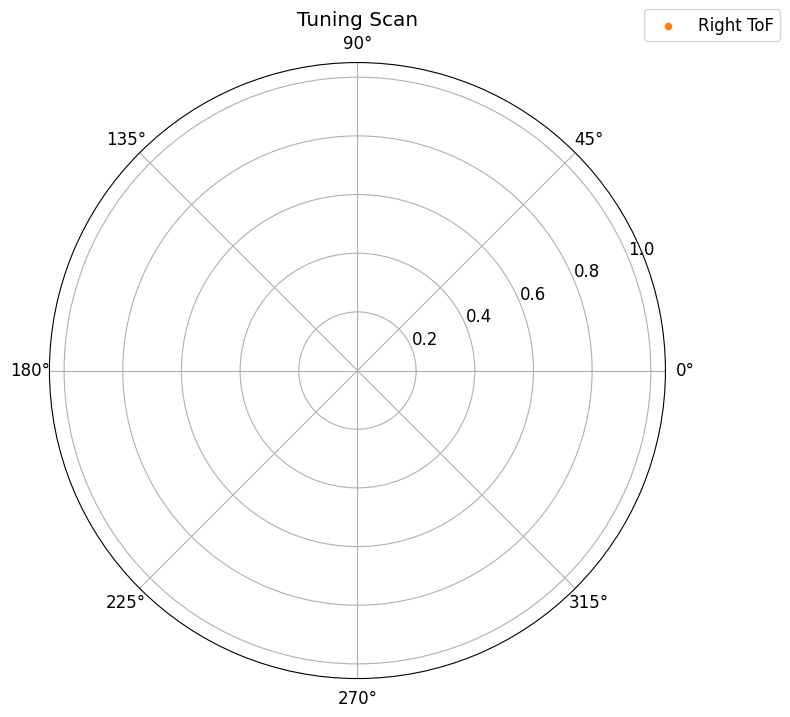

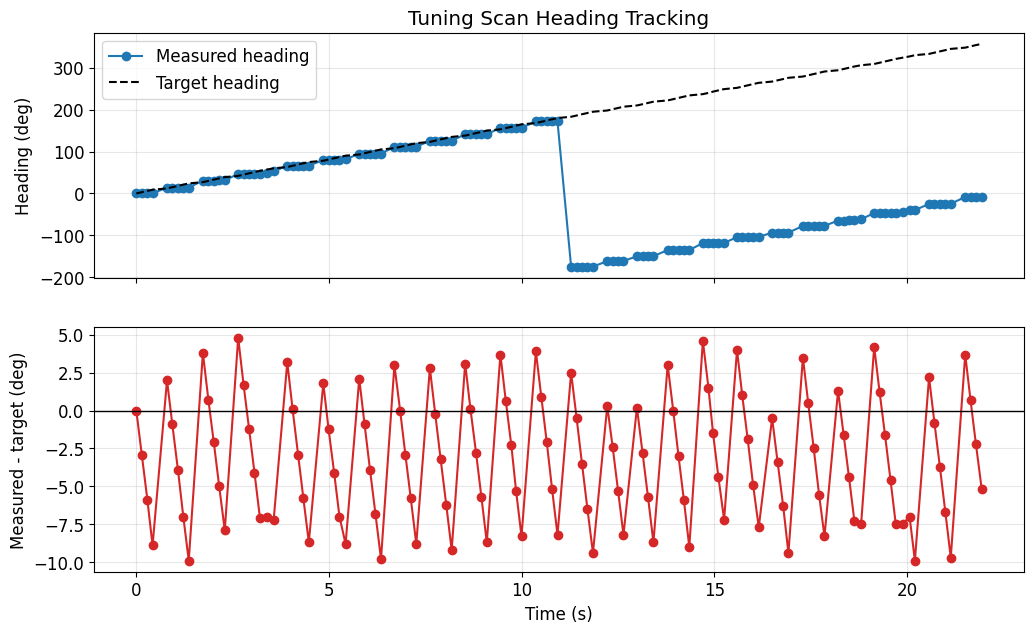

In [63]:
def plot_polar_scan(df, title=''):
    if df.empty:
        print('No data to plot.')
        return

    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111, projection='polar')
    right = df[df['right_valid']].copy()
    right_theta = np.deg2rad(right['heading_deg'] + RIGHT_SENSOR_YAW_DEG)
    ax.scatter(right_theta, right['right_ft'],
               s=20, c='tab:orange', label='Right ToF')

    ax.set_theta_zero_location('E')
    ax.set_theta_direction(1)
    ax.set_title(title or df['scan_name'].iloc[0])
    ax.legend(loc='upper right', bbox_to_anchor=(1.2, 1.1))
    plt.show()

def plot_heading_error(df, title='Heading Error'):
    if df.empty:
        print('No data to plot.')
        return
    fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
    axes[0].plot(df['time_s'], df['heading_deg'], 'o-', label='Measured heading')
    axes[0].plot(df['time_s'], df['target_deg'], 'k--', label='Target heading')
    axes[0].set_ylabel('Heading (deg)')
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    axes[0].set_title(title)

    axes[1].plot(df['time_s'], df['heading_err_deg'], 'o-', color='tab:red')
    axes[1].axhline(0.0, color='k', lw=1)
    axes[1].set_xlabel('Time (s)')
    axes[1].set_ylabel('Measured - target (deg)')
    axes[1].grid(alpha=0.3)
    plt.show()

# Example plots for the latest tuning scan.
plot_polar_scan(df_tune, title='Tuning Scan')
plot_heading_error(df_tune, title='Tuning Scan Heading Tracking')


## 11. Transform All Scans Into the Room Frame

In [64]:
def rot2(theta_deg):
    th = np.deg2rad(theta_deg)
    c, s = np.cos(th), np.sin(th)
    return np.array([[c, -s], [s, c]])

def sensor_hits_room(df, pose, sensor='front'):
    if sensor == 'front':
        valid = df['front_valid']
        ranges_ft = df.loc[valid, 'front_ft'].to_numpy()
        headings_deg = df.loc[valid, 'heading_deg'].to_numpy()
        sensor_offset = FRONT_SENSOR_OFFSET_FT
        sensor_yaw_deg = FRONT_SENSOR_YAW_DEG
    elif sensor == 'right':
        valid = df['right_valid']
        ranges_ft = df.loc[valid, 'right_ft'].to_numpy()
        headings_deg = df.loc[valid, 'heading_deg'].to_numpy()
        sensor_offset = RIGHT_SENSOR_OFFSET_FT
        sensor_yaw_deg = RIGHT_SENSOR_YAW_DEG
    else:
        raise ValueError('sensor must be front or right')

    if len(ranges_ft) == 0:
        return pd.DataFrame(columns=['scan_name', 'sensor', 'x_ft', 'y_ft', 'heading_deg', 'range_ft'])

    rows = []
    room_origin = np.array([pose['x_ft'] + pose.get('dx_ft', 0.0),
                            pose['y_ft'] + pose.get('dy_ft', 0.0)])
    theta0_corr = pose['theta0_deg'] + pose.get('dtheta_deg', 0.0)
    for heading_deg, rng_ft in zip(headings_deg, ranges_ft):
        body_to_room = rot2(theta0_corr + heading_deg + ROBOT_YAW_OFFSET_DEG)
        ray_body = np.array([
            np.cos(np.deg2rad(sensor_yaw_deg)),
            np.sin(np.deg2rad(sensor_yaw_deg)),
        ]) * rng_ft
        hit_room = room_origin + body_to_room @ (sensor_offset + ray_body)
        rows.append({
            'scan_name': df['scan_name'].iloc[0],
            'sensor': sensor,
            'x_ft': hit_room[0],
            'y_ft': hit_room[1],
            'heading_deg': heading_deg,
            'range_ft': rng_ft,
            'pass_name': df['pass_name'].iloc[0],
        })
    return pd.DataFrame(rows)

def build_global_points(scan_runs, sensor=ACTIVE_SENSOR):
    chunks = []
    for name, entry in scan_runs.items():
        df = entry['df']
        pose = entry['pose']
        if df.empty:
            continue
        chunks.append(sensor_hits_room(df, pose, sensor=sensor))
    if not chunks:
        return pd.DataFrame(columns=['scan_name', 'sensor', 'x_ft', 'y_ft'])
    return pd.concat(chunks, ignore_index=True)

def filter_points_by_range(points_df, min_range_ft=MIN_VALID_RANGE_FT,
                           max_range_ft=MAX_VALID_RANGE_FT):
    if points_df.empty:
        return points_df.copy()

    keep_mask = points_df['range_ft'].between(min_range_ft, max_range_ft, inclusive='both')
    filtered = points_df.loc[keep_mask].copy().reset_index(drop=True)
    removed = int((~keep_mask).sum())
    print(f'Range filter: kept {len(filtered)}/{len(points_df)} points, removed {removed}')
    return filtered

def filter_isolated_points(points_df, radius_ft=OUTLIER_RADIUS_FT,
                           min_neighbors=OUTLIER_MIN_NEIGHBORS):
    if points_df.empty:
        return points_df.copy()
    if len(points_df) <= min_neighbors:
        return points_df.copy()

    xy = points_df[['x_ft', 'y_ft']].to_numpy(dtype=float)
    diffs = xy[:, None, :] - xy[None, :, :]
    dist2 = np.sum(diffs * diffs, axis=2)
    neighbor_counts = (dist2 <= radius_ft ** 2).sum(axis=1) - 1
    keep_mask = neighbor_counts >= min_neighbors

    filtered = points_df.loc[keep_mask].copy().reset_index(drop=True)
    removed = int((~keep_mask).sum())
    print(f'Optional isolated-point filter: kept {len(filtered)}/{len(points_df)} points, removed {removed}')
    return filtered

def plot_global_points(points_df, show_scan_origins=True):
    if points_df.empty:
        print('No global points to plot.')
        return

    fig, ax = plt.subplots(figsize=(8, 8))
    markers = {'pass_a_cw': 'o', 'pass_b_ccw': '^', 'tune_cw': 's'}
    for scan_name, group in points_df.groupby('scan_name'):
        pass_name = group['pass_name'].iloc[0] if 'pass_name' in group else 'pass'
        marker = markers.get(pass_name, 'o')
        ax.scatter(group['x_ft'], group['y_ft'], s=22, alpha=0.75,
                   marker=marker, label=scan_name)

    if show_scan_origins:
        for name, entry in scan_runs.items():
            pose = entry['pose']
            x0 = pose['x_ft'] + pose.get('dx_ft', 0.0)
            y0 = pose['y_ft'] + pose.get('dy_ft', 0.0)
            ax.plot(x0, y0, 'kx', ms=10, mew=2)
            ax.text(x0 + 0.08, y0 + 0.08, name, fontsize=9)

    ax.set_aspect('equal', adjustable='box')
    ax.set_xlabel('x (ft)')
    ax.set_ylabel('y (ft)')
    ax.set_title('Merged Lab 9 Map in Room Frame')
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
    plt.show()

global_points_raw = build_global_points(scan_runs, sensor=ACTIVE_SENSOR)
global_points = filter_points_by_range(global_points_raw)
plot_global_points(global_points)
global_points.head()


No global points to plot.


,scan_name,sensor,x_ft,y_ft,heading_deg,range_ft


## 12. Manual Line-Based Map

After inspecting the scatter plot, enter your manually estimated wall or obstacle segments below. These lists are the final simulator-ready map output for later labs.

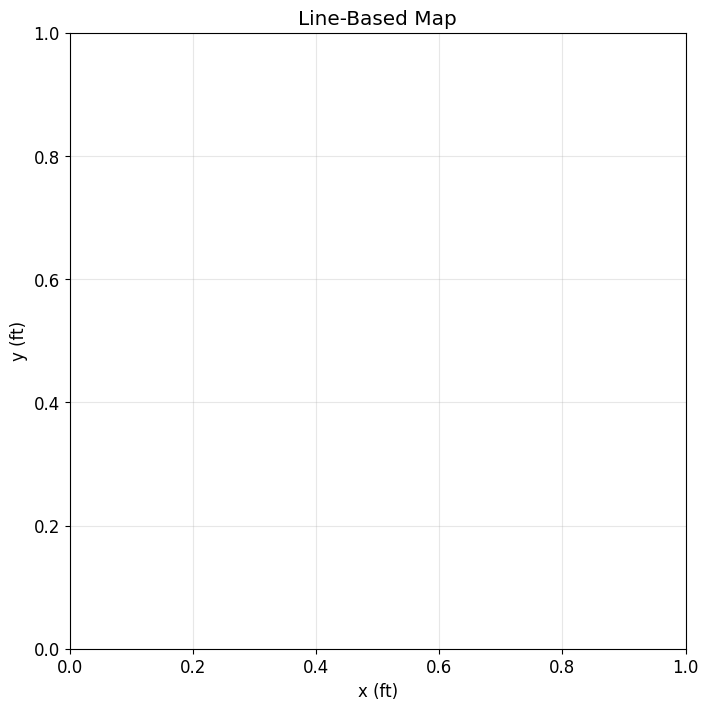

line_starts = []
line_ends   = []


In [65]:
# Fill these in after you inspect the scatter plot.
# Example format:
# line_starts = [(x1, y1), (x2, y2)]
# line_ends   = [(x1b, y1b), (x2b, y2b)]

line_starts = []
line_ends = []

def plot_line_map(points_df, line_starts, line_ends):
    fig, ax = plt.subplots(figsize=(8, 8))
    if not points_df.empty:
        ax.scatter(points_df['x_ft'], points_df['y_ft'], s=18, alpha=0.35, color='tab:blue')

    for (x0, y0), (x1, y1) in zip(line_starts, line_ends):
        ax.plot([x0, x1], [y0, y1], 'r-', lw=2.5)

    ax.set_aspect('equal', adjustable='box')
    ax.set_xlabel('x (ft)')
    ax.set_ylabel('y (ft)')
    ax.set_title('Line-Based Map')
    ax.grid(alpha=0.3)
    plt.show()

plot_line_map(global_points, line_starts, line_ends)
print('line_starts =', line_starts)
print('line_ends   =', line_ends)


## 13. Disconnect

In [66]:
# Run this when you are done.
# ble.disconnect()
# print('Disconnected from Artemis.')
